In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.metrics import r2_score

In [9]:
df = pd.read_csv("FINAL_DATASET_PREDICTION_CEjour.csv")

df["DATE"] = pd.to_datetime(df["DATE"])

print(df.shape)

(485774, 33)


In [23]:
# ==============================
# PHYSICS FEATURES (NO LEAKAGE)
# ==============================


# Pressure difference (important physically)
df["DELTA_P"] = df["WHP"] - df["WHT"]

# GOR (Gas-Oil Ratio) → shifted to avoid leakage
df["GOR"] = df["W_GAS"] / (df["COND_VOL"] + 1e-6)
df["GOR_LAG_1"] = df.groupby("WELL")["GOR"].shift(1)

# Water Cut → shifted
df["WC"] = df["WATER"] / (df["WATER"] + df["COND_VOL"] + 1e-6)
df["WC_LAG_1"] = df.groupby("WELL")["WC"].shift(1)

# Decline (production drop)
df["GAS_DECLINE"] = df.groupby("WELL")["W_GAS"].diff().shift(1)

# Fill NaN created by shift/diff
df.fillna(0, inplace=True)

,DATE,WELL,HOURS,WHP,WHT,W_GAS,WATER,COND_VOL,DELTA_DAYS,WHP_LAG_1,...,COND_VOL_MEAN_7,DAY,MONTH,DAY_OF_WEEK,DELTA_P,GOR,GOR_LAG_1,WC,WC_LAG_1,GAS_DECLINE
0,1999-03-29,TFT-302,3.5,100.0,47.0,0.056289,0.085220,11.448846,1.0,0.0,...,0.000000,29,3,0,53.0,0.004917,0.000000,0.007389,0.000000,0.000000
1,1999-04-01,TFT-302,8.3,100.0,53.0,0.127752,0.229435,24.612087,3.0,100.0,...,0.000000,1,4,3,47.0,0.005191,0.004917,0.009236,0.007389,0.000000
2,1999-04-04,TFT-302,15.8,100.0,52.0,0.243890,0.438012,46.986710,3.0,100.0,...,0.000000,4,4,6,48.0,0.005191,0.005191,0.009236,0.009236,0.071462
3,1999-04-05,TFT-302,24.0,99.0,54.0,0.371549,0.662891,71.110085,1.0,100.0,...,0.000000,5,4,0,45.0,0.005225,0.005191,0.009236,0.009236,0.116138
4,1999-04-06,TFT-302,24.0,100.0,55.0,0.371642,0.667447,71.598801,1.0,99.0,...,0.000000,6,4,1,45.0,0.005191,0.005225,0.009236,0.009236,0.127660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485769,2003-01-27,TFY-30,24.0,102.0,62.0,0.360844,1.839730,66.318222,1.0,104.0,...,66.318222,27,1,0,40.0,0.005441,0.005441,0.026992,0.026992,0.000000
485770,2003-01-28,TFY-30,24.0,102.0,62.0,0.360844,1.839730,66.318222,1.0,102.0,...,66.318222,28,1,1,40.0,0.005441,0.005441,0.026992,0.026992,0.000000
485771,2003-01-29,TFY-30,24.0,103.0,62.0,0.360844,1.839730,66.318222,1.0,102.0,...,66.318222,29,1,2,41.0,0.005441,0.005441,0.026992,0.026992,0.000000
485772,2003-01-30,TFY-30,24.0,104.0,62.0,0.360844,1.839730,66.318222,1.0,103.0,...,66.318222,30,1,3,42.0,0.005441,0.005441,0.026992,0.026992,0.000000


In [24]:
with open("split.json", "r") as f:
    split = json.load(f)

train_wells = split["train"]
blind_wells = split["blind"]

print("Blind wells:", blind_wells)

Blind wells: ['TFT-333Z', 'TFTW-398', 'TFT-391', 'TFTW-397', 'TFT-330', 'TFT-370', 'TFT-386', 'TFT-320', 'TFT-361']


In [25]:
df_blind = df[
    df["WELL"].isin(blind_wells)
].copy()

print(df_blind.shape)

(42970, 39)


In [26]:
features = [
    # RAW
    "WHP","WHT",

    # LAGS
    "WHP_LAG_3","WHP_LAG_7",
    "WHT_LAG_3","WHT_LAG_7",
    "GAS_LAG_1","GAS_LAG_3",
    "GAS_LAG_7",
    "WATER_LAG_1","WATER_LAG_3","WATER_LAG_7",
    "COND_LAG_1","COND_LAG_3","COND_LAG_7",

    # ROLLING
    "W_GAS_MEAN_3","W_GAS_MEAN_7",
    "WATER_MEAN_3","WATER_MEAN_7",
    "COND_VOL_MEAN_3","COND_VOL_MEAN_7",

    # PHYSICS 🔥
    "DELTA_P",
    "GOR_LAG_1",
    "WC_LAG_1",
    "GAS_DECLINE",
    "DELTA_DAYS",

    # TIME
    "DAY","MONTH","DAY_OF_WEEK"
]

targets = ["W_GAS","WATER","COND_VOL"]

In [27]:
X_blind = df_blind[features]
y_blind = df_blind[targets]

In [28]:
xgb_model = joblib.load("models/XGBoost.pkl")

In [29]:
y_pred = xgb_model.predict(X_blind)

print(y_pred.shape)

(42970, 3)


In [30]:
df_anomaly = df_blind.copy().reset_index(drop=True)

# predictions
df_anomaly["PRED_GAS"] = y_pred[:,0]
df_anomaly["PRED_WATER"] = y_pred[:,1]
df_anomaly["PRED_COND"] = y_pred[:,2]

# residuals
df_anomaly["ERROR_GAS"] = (
    df_anomaly["W_GAS"] - df_anomaly["PRED_GAS"]
)

df_anomaly["ERROR_WATER"] = (
    df_anomaly["WATER"] - df_anomaly["PRED_WATER"]
)

df_anomaly["ERROR_COND"] = (
    df_anomaly["COND_VOL"] - df_anomaly["PRED_COND"]
)

# absolute errors
df_anomaly["ABS_ERROR_GAS"] = (
    df_anomaly["ERROR_GAS"].abs()
)

df_anomaly["ABS_ERROR_WATER"] = (
    df_anomaly["ERROR_WATER"].abs()
)

df_anomaly["ABS_ERROR_COND"] = (
    df_anomaly["ERROR_COND"].abs()
)

print(df_anomaly.head())

        DATE     WELL  HOURS    WHP   WHT     W_GAS     WATER   COND_VOL  \
0 1999-06-23  TFT-320   15.4  110.0  48.0  0.255604  0.494834  51.797440   
1 1999-06-24  TFT-320   24.0  110.0  58.0  0.398373  0.771226  80.729141   
2 1999-06-25  TFT-320   24.0  110.0  58.0  0.398373  0.771226  80.729141   
3 1999-06-26  TFT-320   15.8  110.0  59.0  0.262614  0.508406  53.218094   
4 1999-07-02  TFT-320   15.2  115.0  49.0  0.242020  0.450862  50.239609   

   DELTA_DAYS  WHP_LAG_1  ...  GAS_DECLINE  PRED_GAS  PRED_WATER  PRED_COND  \
0         1.0        0.0  ...    -0.116473 -0.008714    0.402400  -0.320242   
1         1.0      110.0  ...     0.000000  0.154258    2.742889  34.373955   
2         1.0      110.0  ...     0.142769  0.276992    2.648090  66.235741   
3         1.0      110.0  ...     0.000000  0.319644    2.880957  68.810684   
4         6.0      110.0  ...    -0.135758  0.149795    3.814094  25.747837   

   ERROR_GAS  ERROR_WATER  ERROR_COND  ABS_ERROR_GAS  ABS_ERROR_WATE

In [31]:
cols = [
    "ABS_ERROR_GAS",
    "ABS_ERROR_WATER",
    "ABS_ERROR_COND"
]

for col in cols:

    print("\n================")
    print(col)

    print(df_anomaly[col].describe())

    print("95% :", df_anomaly[col].quantile(0.95))
    print("99% :", df_anomaly[col].quantile(0.99))


ABS_ERROR_GAS
count    4.297000e+04
mean     1.094137e-02
std      2.689328e-02
min      1.471419e-07
25%      1.577547e-03
50%      3.511706e-03
75%      8.073713e-03
max      5.922766e-01
Name: ABS_ERROR_GAS, dtype: float64
95% : 0.0486859947773263
99% : 0.140192951905042

ABS_ERROR_WATER
count    42970.000000
mean         0.356833
std          2.074631
min          0.000003
25%          0.007631
50%          0.017317
75%          0.047595
max         52.287893
Name: ABS_ERROR_WATER, dtype: float64
95% : 0.9411003351211537
99% : 8.847257099151559

ABS_ERROR_COND
count    42970.000000
mean         1.840347
std          4.872913
min          0.000004
25%          0.238806
50%          0.543559
75%          1.276259
max        137.082687
Name: ABS_ERROR_COND, dtype: float64
95% : 8.02562661170957
99% : 24.44898773193359


In [33]:
# =========================================

# GAS
gas_q99  = df_anomaly["ABS_ERROR_GAS"].quantile(0.99)
gas_q995 = df_anomaly["ABS_ERROR_GAS"].quantile(0.995)
gas_q999 = df_anomaly["ABS_ERROR_GAS"].quantile(0.999)

# WATER
water_q99  = df_anomaly["ABS_ERROR_WATER"].quantile(0.99)
water_q995 = df_anomaly["ABS_ERROR_WATER"].quantile(0.995)
water_q999 = df_anomaly["ABS_ERROR_WATER"].quantile(0.999)

# COND
cond_q99  = df_anomaly["ABS_ERROR_COND"].quantile(0.99)
cond_q995 = df_anomaly["ABS_ERROR_COND"].quantile(0.995)
cond_q999 = df_anomaly["ABS_ERROR_COND"].quantile(0.999)


In [34]:
# 2. SEVERITY FUNCTION
# =========================================

def severity_level(error, q99, q995, q999):

    if error > q999:
        return "CRITICAL"

    elif error > q995:
        return "HIGH"

    elif error > q99:
        return "MEDIUM"

    else:
        return "NORMAL"

In [36]:
df_anomaly["SEVERITY_GAS"] = df_anomaly["ABS_ERROR_GAS"].apply(
    lambda x: severity_level(x, gas_q99, gas_q995, gas_q999)
)

df_anomaly["SEVERITY_WATER"] = df_anomaly["ABS_ERROR_WATER"].apply(
    lambda x: severity_level(x, water_q99, water_q995, water_q999)
)

df_anomaly["SEVERITY_COND"] = df_anomaly["ABS_ERROR_COND"].apply(
    lambda x: severity_level(x, cond_q99, cond_q995, cond_q999)
)


In [38]:
severity_map = {
    "NORMAL":0,
    "MEDIUM":1,
    "HIGH":2,
    "CRITICAL":3
}

df_anomaly["SCORE_GAS"] = df_anomaly["SEVERITY_GAS"].map(severity_map)
df_anomaly["SCORE_WATER"] = df_anomaly["SEVERITY_WATER"].map(severity_map)
df_anomaly["SCORE_COND"] = df_anomaly["SEVERITY_COND"].map(severity_map)


In [39]:
df_anomaly["TOTAL_SCORE"] = (
    df_anomaly["SCORE_GAS"] +
    df_anomaly["SCORE_WATER"] +
    df_anomaly["SCORE_COND"]
)

In [41]:
def global_severity(score):

    if score >= 7:
        return "CRITICAL"

    elif score >= 5:
        return "HIGH"

    elif score >= 3:
        return "MEDIUM"

    elif score >= 1:
        return "LOW"

    else:
        return "NORMAL"

df_anomaly["GLOBAL_SEVERITY"] = (
    df_anomaly["TOTAL_SCORE"]
    .apply(global_severity)
)


In [42]:
# anomaly if not NORMAL
df_anomaly["IS_ANOMALY"] = (
    df_anomaly["GLOBAL_SEVERITY"] != "NORMAL"
).astype(int)

# rolling count over 5 days
df_anomaly["ROLLING_ANOMALY_5"] = (
    df_anomaly
    .groupby("WELL")["IS_ANOMALY"]
    .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

# persistent anomaly
df_anomaly["PERSISTENT_ANOMALY"] = (
    df_anomaly["ROLLING_ANOMALY_5"] >= 3
).astype(int)

In [44]:
final_anomalies = df_anomaly[[
    "DATE",
    "WELL",

    "W_GAS",
    "PRED_GAS",
    "ABS_ERROR_GAS",
    "SEVERITY_GAS",

    "WATER",
    "PRED_WATER",
    "ABS_ERROR_WATER",
    "SEVERITY_WATER",

    "COND_VOL",
    "PRED_COND",
    "ABS_ERROR_COND",
    "SEVERITY_COND",

    "TOTAL_SCORE",
    "GLOBAL_SEVERITY",
    "ROLLING_ANOMALY_5",
    "PERSISTENT_ANOMALY"
]]

In [45]:
# 9. SAVE
# =========================================

final_anomalies.to_csv(
    "FINAL_ANOMALY_REPORT.csv",
    index=False
)

In [46]:
# 10. SUMMARY
# =========================================

print("\n===== GLOBAL SEVERITY =====")
print(
    final_anomalies["GLOBAL_SEVERITY"]
    .value_counts()
)

print("\n===== PERSISTENT ANOMALIES =====")
print(
    final_anomalies["PERSISTENT_ANOMALY"]
    .value_counts()
)

print("\n===== TOP CRITICAL EVENTS =====")

critical_events = final_anomalies[
    final_anomalies["GLOBAL_SEVERITY"] == "CRITICAL"
]

print(
    critical_events[
        [
            "DATE",
            "WELL",
            "TOTAL_SCORE",
            "ROLLING_ANOMALY_5"
        ]
    ].head(20)
)


===== GLOBAL SEVERITY =====
GLOBAL_SEVERITY
NORMAL      42065
LOW           590
MEDIUM        256
HIGH           57
CRITICAL        2
Name: count, dtype: int64

===== PERSISTENT ANOMALIES =====
PERSISTENT_ANOMALY
0    42496
1      474
Name: count, dtype: int64

===== TOP CRITICAL EVENTS =====
            DATE      WELL  TOTAL_SCORE  ROLLING_ANOMALY_5
38649 2007-07-07  TFTW-397            8                3.0
38919 2008-04-12  TFTW-397            8                1.0


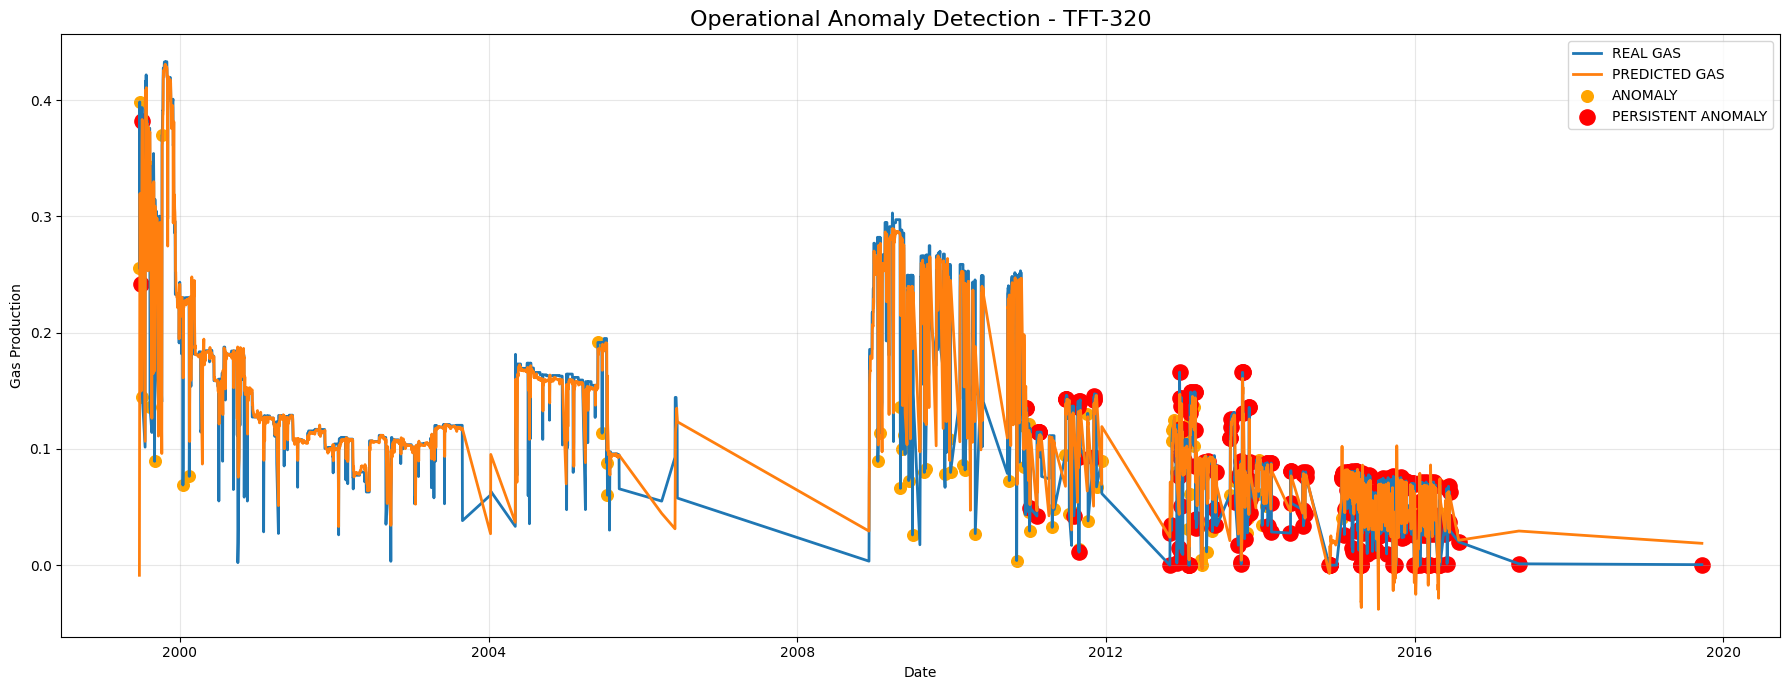

In [48]:
import matplotlib.pyplot as plt

# =========================
# WELL
# =========================

well = df_anomaly["WELL"].unique()[0]

dfp = (
    df_anomaly[df_anomaly["WELL"] == well]
    .sort_values("DATE")
)

# =========================
# ANOMALIES
# =========================

anomalies = dfp[
    dfp["IS_ANOMALY"] == 1
]

persistent = dfp[
    dfp["PERSISTENT_ANOMALY"] == 1
]

# =========================
# PLOT
# =========================

plt.figure(figsize=(18,7))

# REAL
plt.plot(
    dfp["DATE"],
    dfp["W_GAS"],
    label="REAL GAS",
    linewidth=2
)

# PRED
plt.plot(
    dfp["DATE"],
    dfp["PRED_GAS"],
    label="PREDICTED GAS",
    linewidth=2
)

# NORMAL ANOMALIES
plt.scatter(
    anomalies["DATE"],
    anomalies["W_GAS"],
    color="orange",
    s=70,
    label="ANOMALY"
)

# PERSISTENT ANOMALIES
plt.scatter(
    persistent["DATE"],
    persistent["W_GAS"],
    color="red",
    s=120,
    label="PERSISTENT ANOMALY"
)

plt.title(
    f"Operational Anomaly Detection - {well}",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Gas Production")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [49]:
from ipywidgets import interact

wells = df_anomaly["WELL"].unique().tolist()

@interact(well=wells)

def plot_anomaly_well(well):

    dfp = (
        df_anomaly[df_anomaly["WELL"] == well]
        .sort_values("DATE")
    )

    anomalies = dfp[dfp["IS_ANOMALY"] == 1]

    persistent = dfp[dfp["PERSISTENT_ANOMALY"] == 1]

    plt.figure(figsize=(18,7))

    plt.plot(
        dfp["DATE"],
        dfp["W_GAS"],
        label="REAL"
    )

    plt.plot(
        dfp["DATE"],
        dfp["PRED_GAS"],
        label="PREDICTED"
    )

    plt.scatter(
        anomalies["DATE"],
        anomalies["W_GAS"],
        color="orange",
        s=60,
        label="ANOMALY"
    )

    plt.scatter(
        persistent["DATE"],
        persistent["W_GAS"],
        color="red",
        s=120,
        label="PERSISTENT"
    )

    plt.title(f"Gas Operational Anomalies - {well}")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

interactive(children=(Dropdown(description='well', options=('TFT-320', 'TFT-330', 'TFT-333Z', 'TFT-361', 'TFT-…

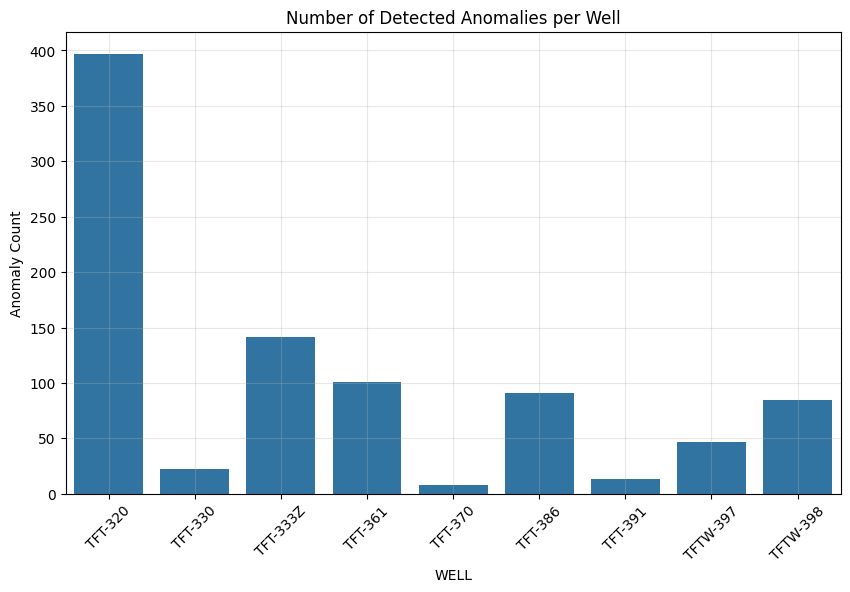

In [50]:
import seaborn as sns

heatmap_data = (
    df_anomaly
    .groupby("WELL")["IS_ANOMALY"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=heatmap_data,
    x="WELL",
    y="IS_ANOMALY"
)

plt.title("Number of Detected Anomalies per Well")

plt.ylabel("Anomaly Count")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()